# Positive Feedback, Bifurcation, and Supplemental Figure Analysis


This notebook has two main goals:

1. **Generate supplemental figures S1–S4** — full time-course/distribution panels across all SOS concentrations for each model, and bifurcation scans confirming the absence of bistability.

2. **Characterize the role of positive feedback** — by systematically eliminating or amplifying the allosteric feedback (Koff2 < Koff1) and comparing results to the mean-field predictions.

In [31]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt
import roadrunner as rr

In [32]:
modelName = "Model1"
#modelName = "Model2"
#modelName = "Model3"

model = bionetgen.bngmodel(modelName + ".bngl") 
sim = model.setup_simulator() 
sim.setIntegrator('gillespie')


## Run and Plot Timecourse 

1.0 7e-08
5.0 3.5000000000000004e-07
10.0 7.000000000000001e-07


Text(0, 0.5, 'counts')

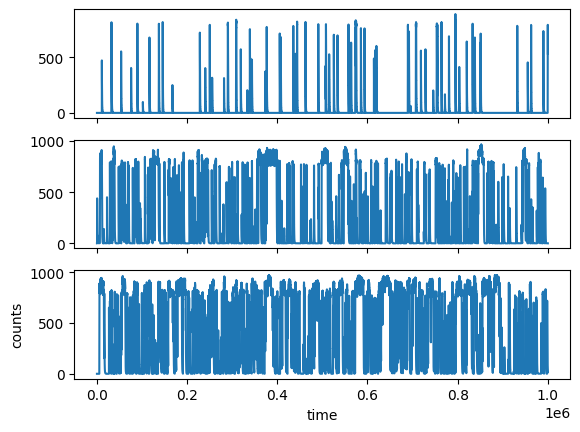

In [33]:

## Run time course trajectories 

snames=['totalRasGTP','totalBoundRas','TotalRas'] # observables
pval = [1, 5, 10] # MODEL 1 and 3  
#pval = [1, 15, 30] # MODEL 2 

traj=[0]*len(pval) 


# for altering parameters in the model , comment out 
# sim.Kcat2=2.5e-2 #multimodal 

Kon= 7e-8  #processive (Models 1 and 2)
#Kon = 7e-5# nonprocessive (Model 3)


for i, p in enumerate(pval):
    sim.RhoSOS= p
    
    sim.Kon1= p*Kon  # manually update Kon1 and Kon2 values 
    sim.Kon2= p*Kon 
    sim.reset()
    print(sim.RhoSOS,sim.Kon1)
    traj[i]= sim.simulate(0,1000000,1000000)

# plot trajectories
fig, axes = plt.subplots(nrows=len(pval), ncols=1, sharex=True) 
for i in range(len(traj)):
    axes[i].plot(traj[i]['time'],traj[i][snames[0]])
axes[-1].set_xlabel('time')
axes[-1].set_ylabel('counts')
#plt.tight_layout()



### Supplemental Figures S1-3

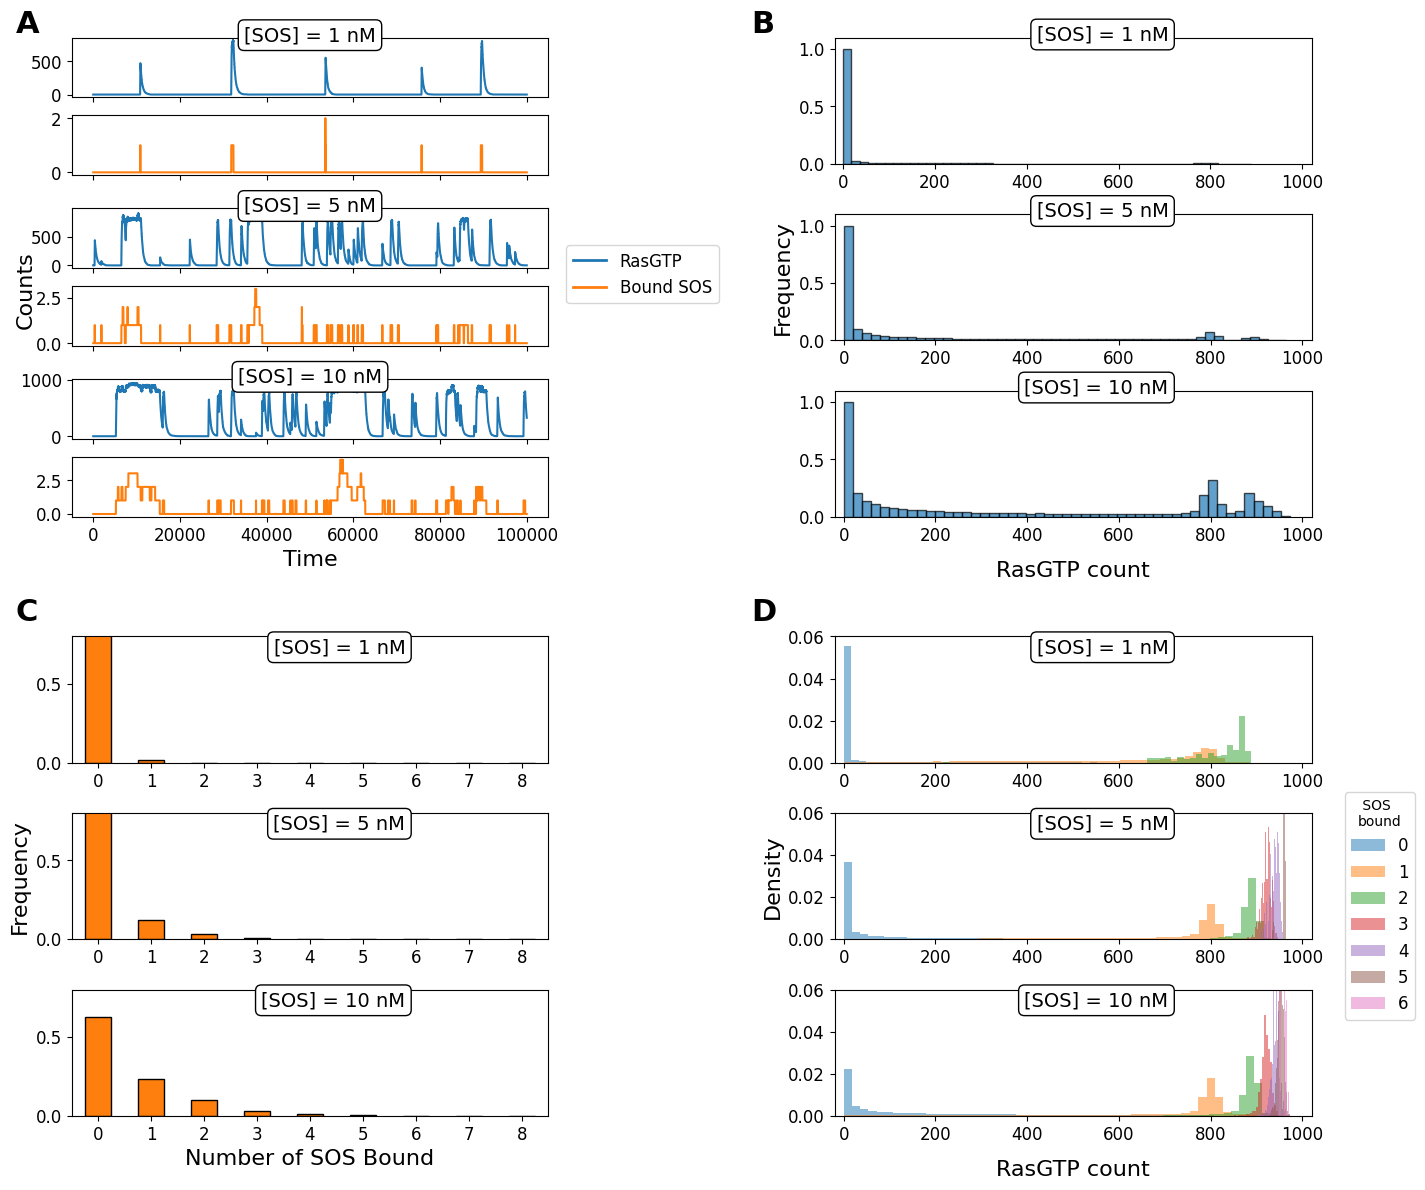

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D


sos_values = [1, 5, 10] #[1,15,30]
indices = [i for i, val in enumerate(pval) if val in sos_values]
n_groups = len(indices)


color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

LABEL_SIZE = 12
AXIS_SIZE = 16
TITLE_SIZE = 14
PANEL_SIZE = 22

fig = plt.figure(figsize=(16, 14))

outer = gridspec.GridSpec(
    2, 2,
    figure=fig,
    wspace=0.6,
    hspace=0.25
)



# PANEL LETTERS
fig.text(
    0.09, 0.9, "A",
    fontsize=PANEL_SIZE,
    fontweight='bold',
    ha='left',
    va='top'
)
fig.text(
    0.55, 0.9, "B",
    fontsize=PANEL_SIZE,
    fontweight='bold',
    ha='left',
    va='top'
)
fig.text(
    0.09, 0.48, "C",
    fontsize=PANEL_SIZE,
    fontweight='bold',
    ha='left',
    va='top'
)
fig.text(
    0.55, 0.48, "D",
    fontsize=PANEL_SIZE,
    fontweight='bold',
    ha='left',
    va='top'
)

#PANEL A 
#  TIME SERIES 
obs = snames[:2]  
n_obs = len(obs)

subplot_height = 1.76
intragroup_spacing = 0.1
intergroup_spacing = 0.55
height_ratios = []
for _ in range(n_groups):
    for _ in range(n_obs):
        height_ratios.append(subplot_height)
        height_ratios.append(intragroup_spacing)
    height_ratios.pop()
    height_ratios.append(intergroup_spacing)
height_ratios.pop()

innerA = gridspec.GridSpecFromSubplotSpec(len(height_ratios), 1,
                                          subplot_spec=outer[0, 0],
                                          height_ratios=height_ratios)
row_idx = 0
axesA_groups = []  

for group_idx, idx in enumerate(indices):
    traj_i = traj[idx]
    time = traj_i['time']
    mask = time <= 100000

    time_trunc = time[mask]
    group_axes = []

    for j, ob in enumerate(obs):
        ax = fig.add_subplot(innerA[row_idx])
        group_axes.append(ax)
        color = color_cycle[j % len(color_cycle)]

        
        pretty = "RasGTP" if "rasgtp" in ob.lower() else "Bound SOS"
        ax.plot(time_trunc, traj_i[ob][mask], color=color)
        ax.tick_params(axis='both', labelsize=12)

        if j == 0:
            ax.text(
                0.5, 1.2, f"[SOS] = {pval[idx]} nM",
                transform=ax.transAxes, ha='center', va='top',
                fontsize=14,
                bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
            )

        if not (group_idx == n_groups - 1 and j == n_obs - 1):
            ax.set_xticklabels([])

        row_idx += 1
        if j != n_obs - 1:
            row_idx += 1

    axesA_groups.append(tuple(group_axes))
    if group_idx != n_groups - 1:
        row_idx += 1


fig.text(0.09, 0.70, "Counts", va='center', rotation='vertical', fontsize=16)

axesA_groups[-1][-1].set_xlabel("Time", fontsize=16)

# legend for the MIDDLE SOS group, placed BETWEEN COLUMNS
mid = n_groups // 2
legend_ax = axesA_groups[mid][-1]  # attach to the lower subplot of the middle group
handles = [
    Line2D([0], [0], color=color_cycle[0], lw=2, label="RasGTP"),
    Line2D([0], [0], color=color_cycle[1], lw=2, label="Bound SOS"),
]
legend_ax.legend(handles=handles,
                 loc="center left", bbox_to_anchor=(1.02, 1.2),
                 frameon=True, fontsize=12, title_fontsize=12)


# PANEL B  RasGTP DISTRIBUTION

innerB = gridspec.GridSpecFromSubplotSpec(n_groups, 1,
                                          subplot_spec=outer[0, 1],
                                          hspace=0.4)
for j, idx in enumerate(indices):
    ax = fig.add_subplot(innerB[j])
    ras_gtp = np.asarray(traj[idx]['totalRasGTP'])
    vmax = np.max(ras_gtp) if ras_gtp.size else 1
    bins = np.linspace(0, vmax, 50)

    counts, _ = np.histogram(ras_gtp, bins=bins)
    counts = counts / counts.max() if counts.max() > 0 else counts
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ax.bar(bin_centers, counts, width=bins[1]-bins[0],
           edgecolor='black', alpha=0.7, color='C0', align='center')
    ax.set_ylim(0, 1.1)

   
    ax.set_xlim(-bins[1], 1020)

    ax.tick_params(labelsize=12)

    ax.text(
        0.7, 1.1, f"[SOS] = {pval[idx]} nM",  # 0.7,0.99
        transform=ax.transAxes, ha='right', va='top',
        fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
    )

    if j == n_groups - 1:
        ax.set_xlabel("RasGTP count", fontsize=16, labelpad=12)
    if j == n_groups // 2:
        ax.set_ylabel("Frequency", fontsize=16)



# PANEL C  SOS BOUND 
innerC = gridspec.GridSpecFromSubplotSpec(n_groups, 1,
                                          subplot_spec=outer[1, 0],
                                          hspace=0.4)
for j, idx in enumerate(indices):
    ax = fig.add_subplot(innerC[j])
    bound = 9
    width = 0.5
    bins_sos = np.arange(bound + 1) - 0.5 * width
    ax.hist(traj[idx]['totalBoundRas'], bins=bins_sos, density=True, align='mid',
            width=width, color='C1', edgecolor='black')
    ax.set_xlim(-0.5, bound - 0.5)
    ax.set_ylim(0, 0.8)
    ax.tick_params(labelsize=12)

    ax.text(
        0.7, 0.99, f"[SOS] = {pval[idx]} nM",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
    )
    if j == n_groups - 1:
        ax.set_xlabel("Number of SOS Bound", fontsize=16)
    if j == n_groups // 2:
        ax.set_ylabel("Frequency", fontsize=16)



# PANEL D CONDITIONAL RasGTP by SOS 

innerD = gridspec.GridSpecFromSubplotSpec(n_groups, 1,
                                          subplot_spec=outer[1, 1],
                                          hspace=0.4)
legend_added = False
for j, idx in enumerate(indices):
    ax = fig.add_subplot(innerD[j])
    traj_i = traj[idx]
    global_smax = int(np.max(traj_i['totalBoundRas']))

    for s in range(global_smax + 1):
        mask = (traj_i['totalBoundRas'] == s)
        ras_gtp = np.asarray(traj_i['totalRasGTP'][mask])
        if ras_gtp.size > 0:
            ax.hist(ras_gtp, bins=50, density=True, alpha=0.5,
                    label=f'{s}', color=color_cycle[s % len(color_cycle)])

    ax.set_xlim(-20, 1020)
    ax.set_ylim(0, 0.06)
    ax.tick_params(labelsize=12)

    if (not legend_added) and j == n_groups - 1:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, title=" SOS\nbound", fontsize=12,
                   bbox_to_anchor=(0.97, 0.26), loc="center right", frameon=True)
        legend_added = True

    ax.text(
        0.7, 0.99, f"[SOS] = {pval[idx]} nM",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
    )

    if j == n_groups - 1:
        ax.set_xlabel("RasGTP count", fontsize=16, labelpad=12)
    if j == n_groups // 2:
        ax.set_ylabel("Density", fontsize=16)

plt.show()


## Bifurcation Analysis - Fig S4

### 3 panel bifurcation analysis for all 3 models 

Forward and backward steady-state scans using the deterministic CVODE integrator. The absence of hysteresis between the forward and backward sweeps confirms that none of the three models exhibit bistability, consistent with Lee et al. (2024).

In [59]:
import pickle
import bionetgen
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


Model1 done.
Model2 done.
Model3 done.


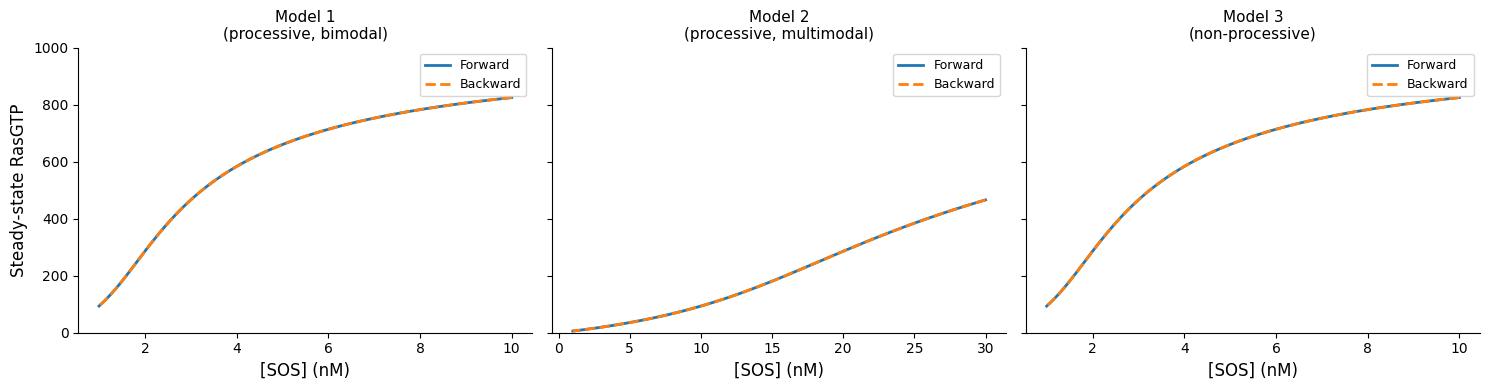

In [61]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

MODELS = ["Model1", "Model2", "Model3"]

PARAMS = {
    'Model1': {
        'kon': 7e-8,
        'koff1': 5e-3,
        'koff2': 5e-4,
        'sos_max': 10,
        'title': 'Model 1\n(processive, bimodal)',
    },
    'Model2': {
        'kon': 7e-8,
        'koff1': 5e-3,
        'koff2': 5e-4,
        'sos_max': 30,
        'title': 'Model 2\n(processive, multimodal)',
    },
    'Model3': {
        'kon': 7e-5,
        'koff1': 5,
        'koff2': 0.5,
        'sos_max': 10,
        'title': 'Model 3\n(non-processive)',
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, MODEL in zip(axes, MODELS):

    p = PARAMS[MODEL]

    sos_range = np.linspace(1, p['sos_max'], 100)

    model_bif = bionetgen.bngmodel(MODEL + ".bngl")
    sim_bif   = model_bif.setup_simulator()

    sim_bif.setIntegrator('cvode')
    sim_bif.selections = ['totalRasGTP']

    ras_fwd = []
    ras_bwd = []

    #  FORWARD SCAN
    sim_bif.reset()

    for sos in sos_range:

        sim_bif.RhoSOS = sos

        sim_bif.Kon1  = sos * p['kon']
        sim_bif.Kon2  = sos * p['kon']

        sim_bif.Koff1 = p['koff1']
        sim_bif.Koff2 = p['koff2']

        out = sim_bif.simulate(0, 1000000, 2)

        ras_fwd.append(out[-1, 0])

    #  BACKWARD SCAN 
    sim_bif.reset()

    for sos in sos_range[::-1]:

        sim_bif.RhoSOS = sos

        sim_bif.Kon1  = sos * p['kon']
        sim_bif.Kon2  = sos * p['kon']

        sim_bif.Koff1 = p['koff1']
        sim_bif.Koff2 = p['koff2']

        out = sim_bif.simulate(0, 1000000, 2)

        ras_bwd.append(out[-1, 0])

    # plotting
    ax.plot(
        sos_range,
        ras_fwd,
        lw=2,
        label='Forward'
    )

    ax.plot(
        sos_range[::-1],
        ras_bwd,
        lw=2,
        ls='--',
        label='Backward'
    )

    ax.set_xlabel('[SOS] (nM)', fontsize=12)
    ax.set_title(p['title'], fontsize=11)

    ax.set_ylim(0, 1000)

    ax.legend(fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(labelsize=10)

    print(f"{MODEL} done.")

axes[0].set_ylabel('Steady-state RasGTP', fontsize=12)

""" fig.suptitle(
    'Bifurcation Plots',
    fontsize=12,
    y=1.02
)"""

plt.tight_layout()
plt.show()

## Positive Feedback 

To isolate the contribution of positive feedback from processivity, we set **Koff1 = Koff2** (removing the differential affinity for RasGTP).

- **Models 1 and 2:** Quantized peaks are preserved. The peak positions ⟨T\*⟩ₙ are unchanged, confirming that processivity—not positive feedback—determines the quantized levels. 
- **Model 3:** Already unimodal, eliminating feedback does not restore quantization but moves singular peak toward lower activation 


### Eliminating Feedback Model 1 


n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 20.0  ]   20.0
1      800.0      12.6     [774.7 , 825.3 ]   50.6
2      888.9      9.9      [869.0 , 908.8 ]   39.8
n=0 -> 30.59%
n=1 -> 5.03%
n=2 -> 0.19%

Total % in windows: 38.5%



/var/folders/_d/lm0617153zx9hgvxqgrdb2lr0000gn/T/ipykernel_58414/3295569595.py:287: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


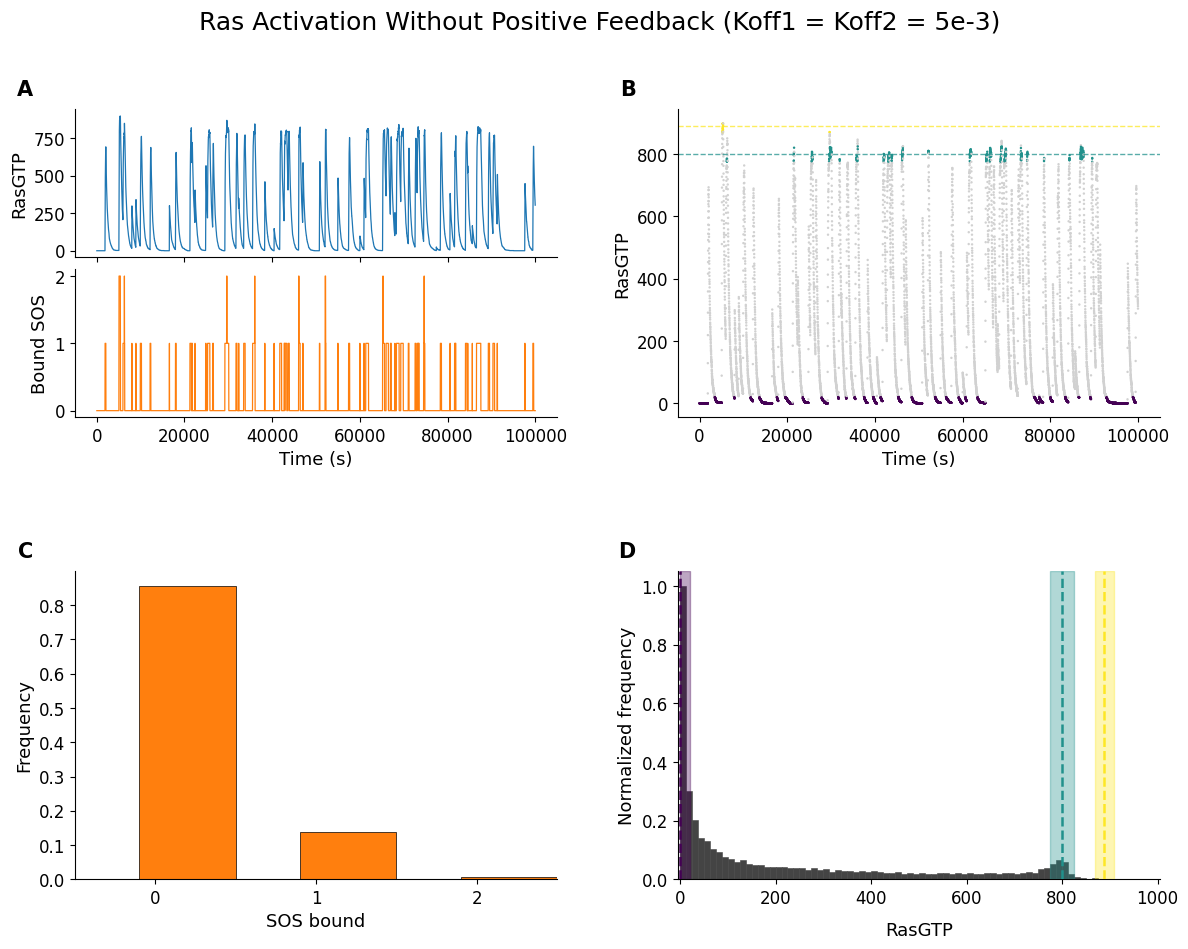

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import bionetgen                      


MODEL      = "Model1"          # prefix for .bngl file and output PNG
PVAL       = [1, 5, 10]        # RhoSOS values (nM)
KOFF1      = 5e-3              # no-feedback: Koff1 = Koff2
KOFF2      = 5e-3
T_END      = 100000               # simulation end time (s)
N_STEPS    = 10000           

Kcat1      = 1e-2              
Kcat2      = 2.5e-3             
RasTotal   = 1000              

N_SIGMA    = 2                 # half-width of occupancy windows (× σ)
N_BINS     = 80                # bins for RasGTP histogram (panel D)


# Model 

model = bionetgen.bngmodel(MODEL + ".bngl")
sim   = model.setup_simulator()
sim.setIntegrator('gillespie')

# Simulation - no positive feedback 

indices    = list(range(len(PVAL)))
traj_no_fb = []

for idx in indices:
    sim.reset()
    sim.Koff1  = KOFF1
    sim.Koff2  = KOFF2 # eliminate positive feedback 
    sim.RhoSOS = PVAL[idx]

    result = sim.simulate(0, T_END, N_STEPS)
    traj_no_fb.append(result)

time_vals     = np.asarray(traj_no_fb[0]["time"])
ras_vals      = np.asarray(traj_no_fb[0]["totalRasGTP"])
boundras_vals = np.asarray(traj_no_fb[0]["totalBoundRas"])


# Theoretical steady-state RasGTP for each SOS occupancy n


def mean_rasgtp(n, Kcat1, Kcat2, RasTotal):
    """Expected RasGTP when n SOS sites are bound."""
    total_rate = n * Kcat1 + Kcat2
    if total_rate == 0:
        return 0.0
    pn = n * Kcat1 / total_rate
    return RasTotal * pn


def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width (standard deviation)."""
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))


def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    +/- n_sigma·σₙ windows around each predicted peak, capped at midpoints between neighbours so windows never overlap.
    """
    sigmas = []
    ranges = []

    for i, n in enumerate(n_bound_list):
        ss  = ss_array[i]
        sig = sigma(n, Kcat1, Kcat2, RasTotal)
        sigmas.append(sig)

        half = 20 if n == 0 else n_sigma * sig
        lo = ss - half
        hi = ss + half

        if i > 0:                          
            lo = max(lo, 0.5 * (ss_array[i - 1] + ss))
        if i < len(ss_array) - 1:         
            hi = min(hi, 0.5 * (ss + ss_array[i + 1]))

        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))

    return ranges, sigmas

max_sos      = int(boundras_vals.max()) if boundras_vals.size else 4
n_bound_list = list(range(max_sos + 1))
R_ss_array   = np.array([mean_rasgtp(n, Kcat1, Kcat2, RasTotal)
                          for n in n_bound_list])

quantized_ranges, sigmas_list = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=N_SIGMA
)

# Tables 
print(f"\n{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} width")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array,
                                 sigmas_list, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")

state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")



colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

def assign_dot_colors(ras_vals, bound_vals, quantized_ranges, n_bound_list, colors):
    """Color per point by occupancy n, grey when outside window."""
    grey   = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)
    for i, ((lo, hi), n) in enumerate(zip(quantized_ranges, n_bound_list)):
        mask = (bound_vals == n) & (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]
    return result

def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """Fraction of histogram within each theory window."""
    total  = counts_norm.sum()
    stats  = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt    = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0,
        })
    return stats

dot_colors = assign_dot_colors(ras_vals, boundras_vals,
                                quantized_ranges, n_bound_list, colors)

# RasGTP histogram (panels D)
counts, edges = np.histogram(ras_vals, bins=N_BINS, range=(0, RasTotal))
counts_norm   = counts / counts.max() if counts.max() > 0 else counts
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

range_stats      = quantize_histogram(counts_norm, bin_centers,
                                      quantized_ranges, n_bound_list, R_ss_array)
pct_quantized    = sum(s['pct'] for s in range_stats)
print(f"\nTotal % in windows: {pct_quantized:.1f}%\n")


# 4 panel figure 

LABEL_SIZE  = 12
AXIS_SIZE   = 13
PANEL_SIZE  = 15

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig   = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.5)

innerA    = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                             hspace=0.08, height_ratios=[1, 1])
ax_A_top  = fig.add_subplot(innerA[0])
ax_A_bot  = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B      = fig.add_subplot(outer[0, 1])
ax_C      = fig.add_subplot(outer[1, 0])
ax_D      = fig.add_subplot(outer[1, 1])

# Panel Labels 
for letter, ax in zip(['A', 'B', 'C', 'D'],
                       [ax_A_top, ax_B, ax_C, ax_D]):
    pos = ax.get_position()
    fig.text(pos.x0 - 0.03, pos.y1 + 0.01, letter,
             fontsize=PANEL_SIZE, fontweight='bold', va='bottom', ha='right')

#  Panel A — Dual time course 
ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)

ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  Panel B - Scatter colored by instantaneous SOS occupancy
ax_B.scatter(time_vals, ras_vals,
             c=dot_colors, s=3, linewidths=0, rasterized=True)

for ss, col in zip(R_ss_array, colors):
    if ss > 0:
        ax_B.axhline(ss, color=col, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time (s)', fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP',   fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

#  Panel C — SOS-bound occupancy histogram 
max_bound    = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_w    = 0.6
sos_bins     = np.arange(max_bound + 2) - 0.5 * sos_bar_w

ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          rwidth=sos_bar_w, color=color_bras,
          edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound', fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency', fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

#  Panel D — Quantized RasGTP histogram 
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444',
         linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.05)
ax_D.set_xlim(-5, RasTotal + 5)

for s, col in zip(range_stats, colors):
    ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=col, zorder=3)
    ax_D.axvline(s['ss_val'], color=col, lw=1.8, ls='--', zorder=4)

ax_D.set_xlabel('RasGTP',              fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)


fig.suptitle(
    "Model 1 Without Positive Feedback (Koff1 = Koff2 = 5e-3)",
    fontsize=18, y=0.98
)

plt.tight_layout()
plt.show()


### Eliminating Feedback Model 2


n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 20.0  ]   20.0
1      285.7      14.3     [257.1 , 314.3 ]   57.1
2      444.4      15.7     [413.0 , 475.9 ]   62.9
3      545.5      15.7     [514.0 , 576.9 ]   63.0
4      615.4      15.4     [584.6 , 641.0 ]   56.4
5      666.7      14.9     [641.0 , 696.5 ]   55.5
n=0 -> 54.24%
n=1 -> 18.89%
n=2 -> 2.84%
n=3 -> 0.54%
n=4 -> 0.17%
n=5 -> 0.01%

Total % in windows: 76.8%



/var/folders/_d/lm0617153zx9hgvxqgrdb2lr0000gn/T/ipykernel_58414/2599399736.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


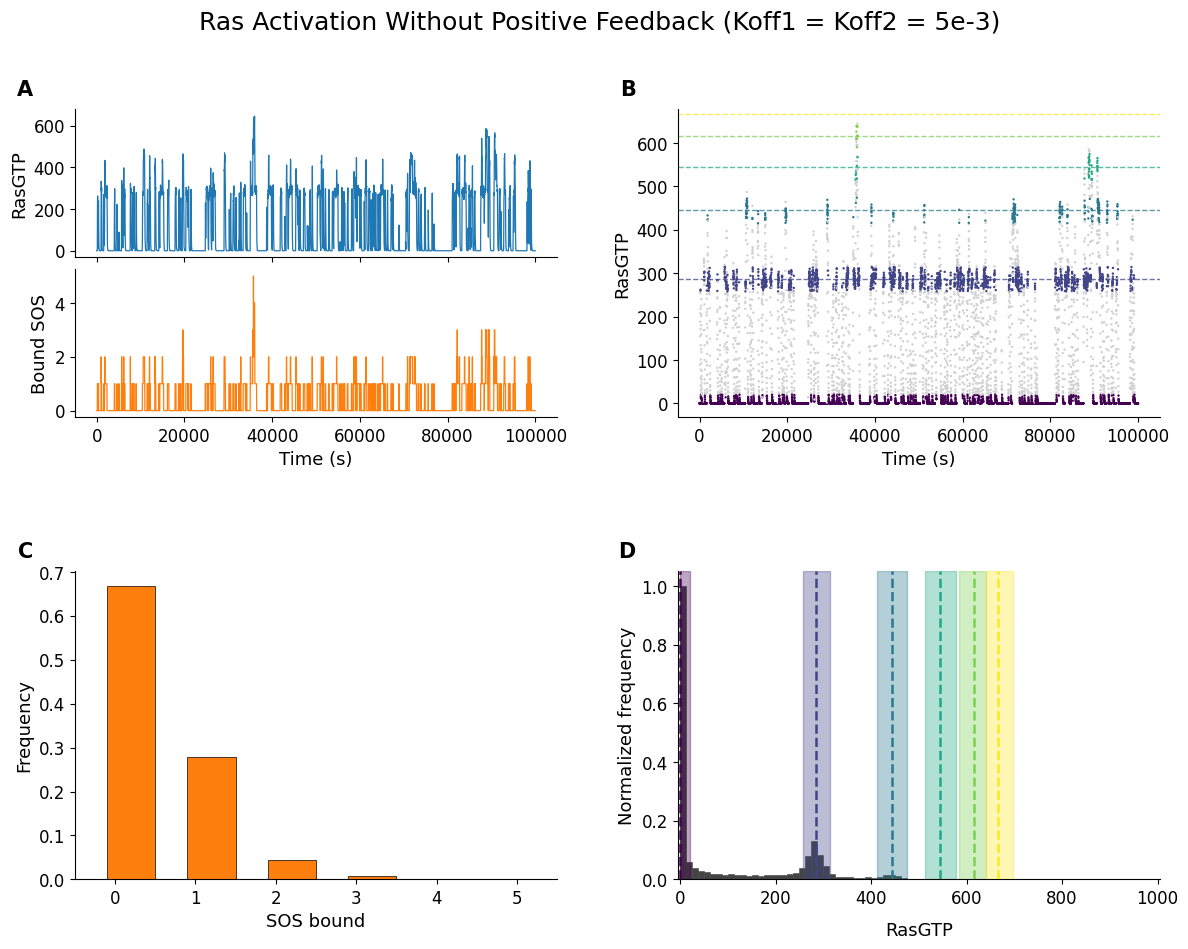

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import bionetgen                      


MODEL      = "Model2"          
PVAL       = [1, 15, 30]        # RhoSOS values (nM)
KOFF1      = 5e-3              # no-feedback: Koff1 = Koff2
KOFF2      = 5e-3
T_END      = 100000               # simulation end time (s)
N_STEPS    = 10000           


Kcat1      = 1e-2             
Kcat2      = 2.5e-2            
RasTotal   = 1000               

N_SIGMA    = 2                 # half-width of occupancy windows (×σ)
N_BINS     = 80                # bins for RasGTP histogram (panel D)


# MODEL 
model = bionetgen.bngmodel(MODEL + ".bngl")
sim   = model.setup_simulator()
sim.setIntegrator('gillespie')

# SIMULATION 

indices    = list(range(len(PVAL)))
traj_no_fb = []

for idx in indices:
    sim.reset()
    sim.Koff1  = KOFF1
    sim.Koff2  = KOFF2
    sim.RhoSOS = PVAL[idx]

    result = sim.simulate(0, T_END, N_STEPS)
    traj_no_fb.append(result)

time_vals     = np.asarray(traj_no_fb[0]["time"])
ras_vals      = np.asarray(traj_no_fb[0]["totalRasGTP"])
boundras_vals = np.asarray(traj_no_fb[0]["totalBoundRas"])

# THEORETICAL PREDICTIONS

def mean_rasgtp(n, Kcat1, Kcat2, RasTotal):
    """Expected RasGTP when n SOS sites are bound."""
    total_rate = n * Kcat1 + Kcat2
    if total_rate == 0:
        return 0.0
    pn = n * Kcat1 / total_rate
    return RasTotal * pn


def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width (standard deviation)."""
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))


def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    ±n_sigma·σₙ windows around each predicted peak,
    capped at midpoints between neighbours so windows never overlap.
    """
    sigmas = []
    ranges = []
    for i, n in enumerate(n_bound_list):
        ss  = ss_array[i]
        sig = sigma(n, Kcat1, Kcat2, RasTotal)
        sigmas.append(sig)

        half = 20 if n == 0 else n_sigma * sig
        lo = ss - half
        hi = ss + half

        if i > 0:                          
            lo = max(lo, 0.5 * (ss_array[i - 1] + ss))
        if i < len(ss_array) - 1:         
            hi = min(hi, 0.5 * (ss + ss_array[i + 1]))

        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))

    return ranges, sigmas

max_sos      = int(boundras_vals.max()) if boundras_vals.size else 4
n_bound_list = list(range(max_sos + 1))
R_ss_array   = np.array([mean_rasgtp(n, Kcat1, Kcat2, RasTotal)
                          for n in n_bound_list])

quantized_ranges, sigmas_list = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=N_SIGMA
)

# TABLES
print(f"\n{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} width")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array,
                                 sigmas_list, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")

state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")


# FOR PLOTTING

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

def assign_dot_colors(ras_vals, bound_vals, quantized_ranges, n_bound_list, colors):
    """COLOR by occupancy n, grey when outside window."""
    grey   = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)
    for i, ((lo, hi), n) in enumerate(zip(quantized_ranges, n_bound_list)):
        mask = (bound_vals == n) & (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]
    return result


def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """Fraction of histogram within each theory window."""
    total  = counts_norm.sum()
    stats  = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt    = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0,
        })
    return stats

dot_colors = assign_dot_colors(ras_vals, boundras_vals,
                                quantized_ranges, n_bound_list, colors)
# RasGTP histogram (panels D)
counts, edges = np.histogram(ras_vals, bins=N_BINS, range=(0, RasTotal))
counts_norm   = counts / counts.max() if counts.max() > 0 else counts
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

range_stats      = quantize_histogram(counts_norm, bin_centers,
                                      quantized_ranges, n_bound_list, R_ss_array)
pct_quantized    = sum(s['pct'] for s in range_stats)
print(f"\nTotal % in windows: {pct_quantized:.1f}%\n")

# 4 panel figure 

LABEL_SIZE  = 12
AXIS_SIZE   = 13
PANEL_SIZE  = 15

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig   = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.5)

innerA    = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                             hspace=0.08, height_ratios=[1, 1])
ax_A_top  = fig.add_subplot(innerA[0])
ax_A_bot  = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B      = fig.add_subplot(outer[0, 1])
ax_C      = fig.add_subplot(outer[1, 0])
ax_D      = fig.add_subplot(outer[1, 1])

#  Panel labels 
for letter, ax in zip(['A', 'B', 'C', 'D'],
                       [ax_A_top, ax_B, ax_C, ax_D]):
    pos = ax.get_position()
    fig.text(pos.x0 - 0.03, pos.y1 + 0.01, letter,
             fontsize=PANEL_SIZE, fontweight='bold', va='bottom', ha='right')

#  Panel A — Dual time course 
ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)

ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  Panel B — Scatter colored by instantaneous SOS occupancy
ax_B.scatter(time_vals, ras_vals,
             c=dot_colors, s=3, linewidths=0, rasterized=True)

for ss, col in zip(R_ss_array, colors):
    if ss > 0:
        ax_B.axhline(ss, color=col, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time (s)', fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP',   fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

#  Panel C — SOS-bound occupancy histogram 
max_bound    = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_w    = 0.6
sos_bins     = np.arange(max_bound + 2) - 0.5 * sos_bar_w

ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          rwidth=sos_bar_w, color=color_bras,
          edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound', fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency', fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

#  Panel D — Quantized RasGTP histogram 
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444',
         linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.05)
ax_D.set_xlim(-5, RasTotal + 5)

for s, col in zip(range_stats, colors):
    ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=col, zorder=3)
    ax_D.axvline(s['ss_val'], color=col, lw=1.8, ls='--', zorder=4)

ax_D.set_xlabel('RasGTP',              fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)


fig.suptitle(
    "Model 2 Without Positive Feedback (Koff1 = Koff2 = 5e-3)",
    fontsize=18, y=0.98
)

plt.tight_layout()
plt.show()



n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 20.0  ]   20.0
1      285.7      14.3     [257.1 , 314.3 ]   57.1
2      444.4      15.7     [413.0 , 475.9 ]   62.9
3      545.5      15.7     [514.0 , 576.9 ]   63.0
4      615.4      15.4     [584.6 , 641.0 ]   56.4
5      666.7      14.9     [641.0 , 686.3 ]   45.2
6      705.9      14.4     [686.3 , 721.4 ]   35.1
7      736.8      13.9     [721.4 , 749.4 ]   28.0
8      761.9      13.5     [749.4 , 772.3 ]   22.9
9      782.6      13.0     [772.3 , 791.3 ]   19.0
10     800.0      12.6     [791.3 , 825.3 ]   34.0
n=0 -> 0.34%
n=1 -> 6.30%
n=2 -> 7.56%
n=3 -> 13.37%
n=4 -> 11.99%
n=5 -> 16.37%
n=6 -> 19.44%
n=7 -> 10.28%
n=8 -> 6.40%
n=9 -> 3.48%
n=10 -> 1.37%

Total % in windows: 96.2%



/var/folders/_d/lm0617153zx9hgvxqgrdb2lr0000gn/T/ipykernel_58414/2389883643.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


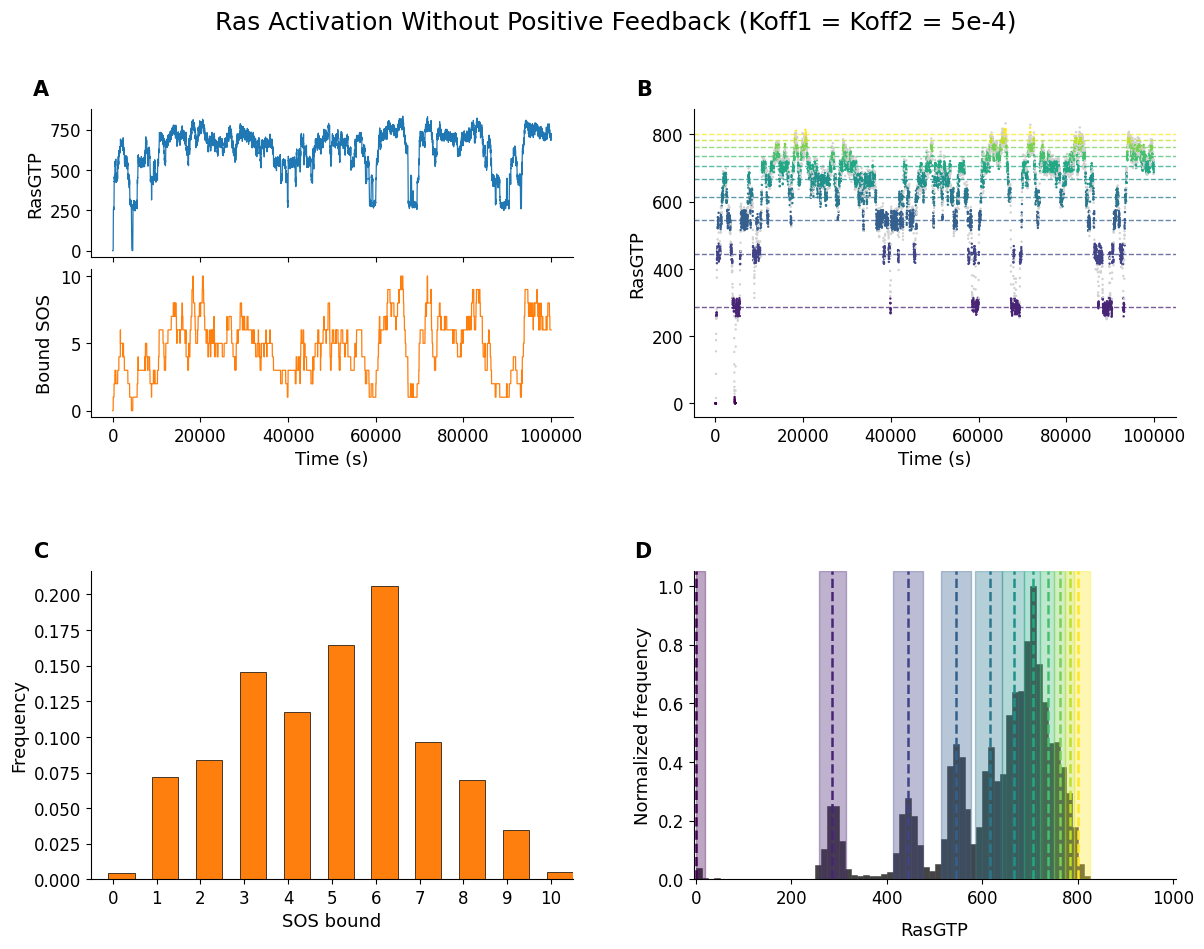

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import bionetgen                      


MODEL      = "Model2"          
PVAL       = [1, 15, 30]        # RhoSOS values (nM)
KOFF1      = 5e-4              # no-feedback: Koff1 = Koff2
KOFF2      = 5e-4
T_END      = 100000               # simulation end time (s)
N_STEPS    = 10000          


Kcat1      = 1e-2             
Kcat2      = 2.5e-2            
RasTotal   = 1000               

N_SIGMA    = 2                 # half-width of occupancy windows (×σ)
N_BINS     = 80                # bins for RasGTP histogram (panel D)

# MODEL
model = bionetgen.bngmodel(MODEL + ".bngl")
sim   = model.setup_simulator()
sim.setIntegrator('gillespie')


# SIMULATION (no positive feedback)
indices    = list(range(len(PVAL)))
traj_no_fb = []

for idx in indices:
    sim.reset()
    sim.Koff1  = KOFF1
    sim.Koff2  = KOFF2
    sim.RhoSOS = PVAL[idx]

    result = sim.simulate(0, T_END, N_STEPS)
    traj_no_fb.append(result)


time_vals     = np.asarray(traj_no_fb[0]["time"])
ras_vals      = np.asarray(traj_no_fb[0]["totalRasGTP"])
boundras_vals = np.asarray(traj_no_fb[0]["totalBoundRas"])

# Theoretical 

def mean_rasgtp(n, Kcat1, Kcat2, RasTotal):
    """Expected RasGTP when n SOS sites are bound."""
    total_rate = n * Kcat1 + Kcat2
    if total_rate == 0:
        return 0.0
    pn = n * Kcat1 / total_rate
    return RasTotal * pn


def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width (standard deviation)."""
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))


def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    +/- n_sigma·σₙ windows around each predicted peak, capped at midpoints between neighbours so windows never overlap.
    """
    sigmas = []
    ranges = []

    for i, n in enumerate(n_bound_list):
        ss  = ss_array[i]
        sig = sigma(n, Kcat1, Kcat2, RasTotal)
        sigmas.append(sig)

        half = 20 if n == 0 else n_sigma * sig
        lo = ss - half
        hi = ss + half

        if i > 0:                          # cap left edge
            lo = max(lo, 0.5 * (ss_array[i - 1] + ss))
        if i < len(ss_array) - 1:         # cap right edge
            hi = min(hi, 0.5 * (ss + ss_array[i + 1]))

        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))

    return ranges, sigmas

max_sos      = int(boundras_vals.max()) if boundras_vals.size else 4
n_bound_list = list(range(max_sos + 1))
R_ss_array   = np.array([mean_rasgtp(n, Kcat1, Kcat2, RasTotal)
                          for n in n_bound_list])

quantized_ranges, sigmas_list = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=N_SIGMA
)

# Tables 
print(f"\n{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} width")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array,
                                 sigmas_list, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")


state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")

# FOR PLOTTING

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))


def assign_dot_colors(ras_vals, bound_vals, quantized_ranges, n_bound_list, colors):
    """COLOR by occupancy n, grey when outside window."""
    grey   = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)

    for i, ((lo, hi), n) in enumerate(zip(quantized_ranges, n_bound_list)):
        mask = (bound_vals == n) & (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]

    return result


def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """Fraction of histogram within each theory window."""
    total  = counts_norm.sum()
    stats  = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt    = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0,
        })
    return stats


dot_colors = assign_dot_colors(ras_vals, boundras_vals,
                                quantized_ranges, n_bound_list, colors)

# RasGTP histogram (panels D)
counts, edges = np.histogram(ras_vals, bins=N_BINS, range=(0, RasTotal))
counts_norm   = counts / counts.max() if counts.max() > 0 else counts
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

range_stats      = quantize_histogram(counts_norm, bin_centers,
                                      quantized_ranges, n_bound_list, R_ss_array)
pct_quantized    = sum(s['pct'] for s in range_stats)
print(f"\nTotal % in windows: {pct_quantized:.1f}%\n")


# 4 panel figure 

LABEL_SIZE  = 12
AXIS_SIZE   = 13
PANEL_SIZE  = 15

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig   = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.5)

innerA    = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                             hspace=0.08, height_ratios=[1, 1])
ax_A_top  = fig.add_subplot(innerA[0])
ax_A_bot  = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B      = fig.add_subplot(outer[0, 1])
ax_C      = fig.add_subplot(outer[1, 0])
ax_D      = fig.add_subplot(outer[1, 1])

#  Panel labels 
for letter, ax in zip(['A', 'B', 'C', 'D'],
                       [ax_A_top, ax_B, ax_C, ax_D]):
    pos = ax.get_position()
    fig.text(pos.x0 - 0.03, pos.y1 + 0.01, letter,
             fontsize=PANEL_SIZE, fontweight='bold', va='bottom', ha='right')

#  Panel A — Dual time course 
ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)

ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  Panel B — Scatter colored by instantaneous SOS occupancy
ax_B.scatter(time_vals, ras_vals,
             c=dot_colors, s=3, linewidths=0, rasterized=True)

for ss, col in zip(R_ss_array, colors):
    if ss > 0:
        ax_B.axhline(ss, color=col, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time (s)', fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP',   fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

#  Panel C — SOS-bound occupancy histogram 
max_bound    = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_w    = 0.6
sos_bins     = np.arange(max_bound + 2) - 0.5 * sos_bar_w

ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          rwidth=sos_bar_w, color=color_bras,
          edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound', fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency', fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

# ── Panel D — Quantized RasGTP histogram ─────────────────
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444',
         linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.05)
ax_D.set_xlim(-5, RasTotal + 5)

for s, col in zip(range_stats, colors):
    ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=col, zorder=3)
    ax_D.axvline(s['ss_val'], color=col, lw=1.8, ls='--', zorder=4)

ax_D.set_xlabel('RasGTP',              fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)


fig.suptitle(
    "Model 2 Without Positive Feedback (Koff1 = Koff2 = 5e-4)",
    fontsize=18, y=0.98
)

plt.tight_layout()
plt.show()


### Eliminating Feedback Model 3

In Model 3 (non-processive), SOS binding/unbinding is 1000× faster than in Models 1 and 2. Ras effectively experiences a time-averaged SOS occupancy rather than discrete binding events. The system collapses to mean-field behavior.

Here we run Model 3 **with positive feedback eliminated** (Koff1 = Koff2) and compare two predictions:
1. **Mean-field prediction without feedback** 
2. **Simulation-derived mean** — the mean SOS occupancy read directly from the no-feedback trajectory (Koff1=Koff2).

**Expected result:** Because positive feedback has been removed, the simulation mean SOS occupancy closely matches the no-feedback analytical prediction, and the two dashed lines in panel D agree. This confirms that in the original Model 3 (with feedback intact), it is the positive feedback that drives the simulation distribution to *higher* RasGTP than the no-feedback prediction — the divergence of the two dashed lines in Fig. 4D directly measures the feedback contribution.
- **With feedback (Fig. 4D):** red line (simulation mean) lies to the right of green line (no-feedback prediction) → feedback increases mean SOS occupancy.
- **Without feedback (this section below):** red and green lines coincide → simulation matches the no-feedback prediction exactly, as expected.

In [ ]:
# Mean Field Calculations, uncomment For Model 3 
 
# Calculated from simulation 
mean_sos_sim = boundras_vals.mean()
meanRasGTP_sim = RasTotal * (mean_sos_sim * Kcat1) / (mean_sos_sim * Kcat1 + Kcat2)

print(f"Mean SOS occupancy ⟨A*⟩ = {mean_sos_sim:.3f}")
print(f"Simulation-based ⟨T*⟩ = {meanRasGTP_sim:.1f}")


#  Theoretical prediction without positive feedback
RhoSOS = 10
Kon3  = 7e-5
Koff1 = 5.0


k1 = Kon3 * RhoSOS

mean_sos_pred = (RasTotal * k1) / (k1 + Koff1)
meanRasGTP_pred = RasTotal * (mean_sos_pred * Kcat1) / (mean_sos_pred * Kcat1 + Kcat2)

print(f"⟨A*⟩ predicted      = {mean_sos_pred:.3f}")
print(f"⟨A*⟩ simulation     = {mean_sos_sim:.3f}")
print(f"Predicted ⟨T*⟩      = {meanRasGTP_pred:.1f}")


Mean SOS occupancy ⟨A*⟩ = 0.136
Simulation-based ⟨T*⟩ = 352.0
⟨A*⟩ predicted      = 0.140
⟨A*⟩ simulation     = 0.136
Predicted ⟨T*⟩      = 358.9



n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 20.0  ]   20.0
1      800.0      12.6     [774.7 , 825.3 ]   50.6
2      888.9      9.9      [869.0 , 906.0 ]   37.0
3      923.1      8.4      [906.2 , 932.1 ]   25.9
4      941.2      7.4      [932.1 , 956.1 ]   23.9
n=0 -> 0.03%
n=1 -> 0.00%
n=2 -> 0.00%
n=3 -> 0.00%
n=4 -> 0.00%

Total % in windows: 0.0%



/var/folders/_d/lm0617153zx9hgvxqgrdb2lr0000gn/T/ipykernel_58414/2183062006.py:299: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


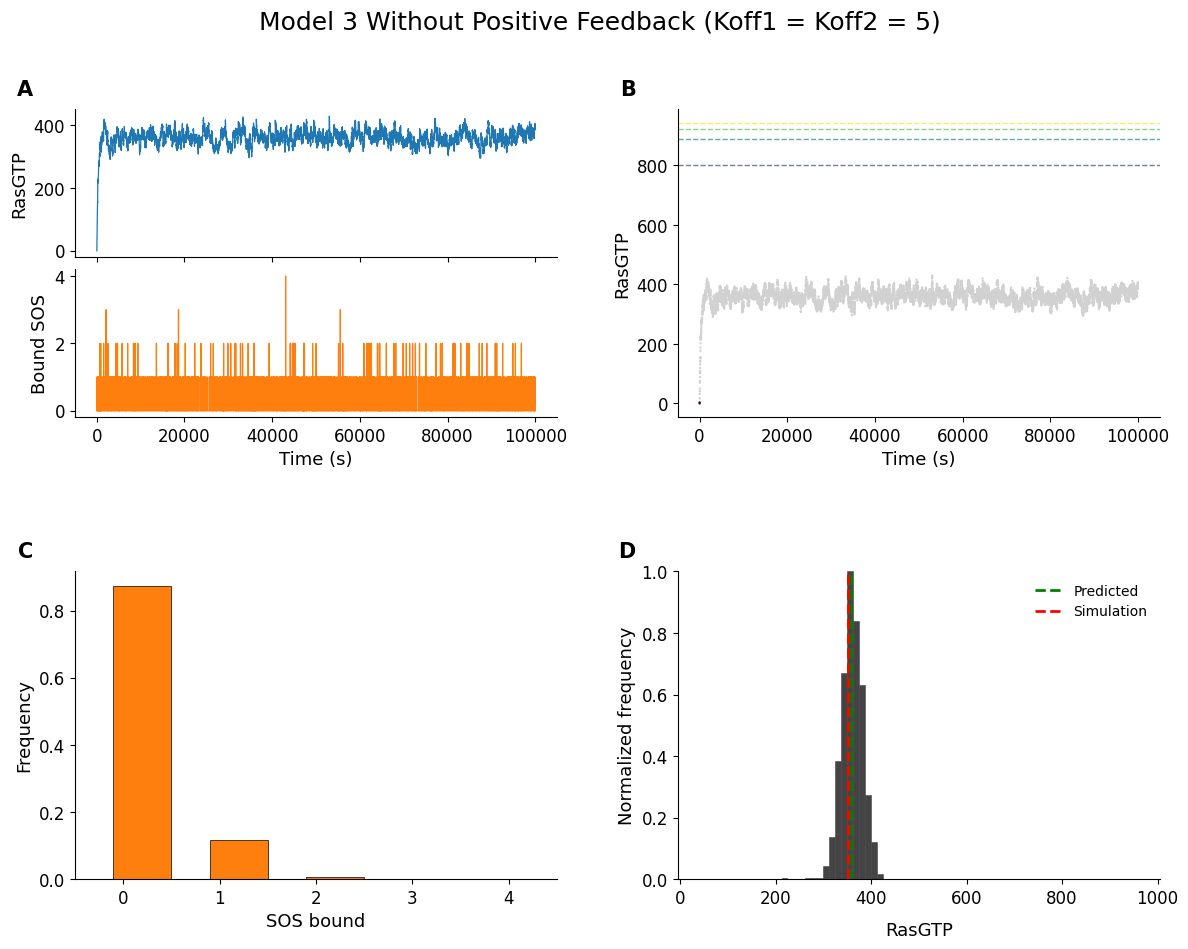

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import bionetgen                       

MODEL      = "Model3"          
PVAL       = [1, 5, 10]        # RhoSOS values (nM)
KOFF1      = 5              # no-feedback: Koff1 = Koff2
KOFF2      = 5
T_END      = 100000               # simulation end time (s)
N_STEPS    = 10000          


Kcat1      = 1e-2              
Kcat2      = 2.5e-3            
RasTotal   = 1000               

N_SIGMA    = 2                 # half-width of occupancy windows (×σ)
N_BINS     = 80                # bins for RasGTP histogram (panel D)

#MODEL

model = bionetgen.bngmodel(MODEL + ".bngl")
sim   = model.setup_simulator()
sim.setIntegrator('gillespie')


#SIMULATIONS  (no positive feedback)


indices    = list(range(len(PVAL)))
traj_no_fb = []

for idx in indices:
    sim.reset()
    sim.Koff1  = KOFF1
    sim.Koff2  = KOFF2
    sim.RhoSOS = PVAL[idx]

    result = sim.simulate(0, T_END, N_STEPS)
    traj_no_fb.append(result)

time_vals     = np.asarray(traj_no_fb[0]["time"])
ras_vals      = np.asarray(traj_no_fb[0]["totalRasGTP"])
boundras_vals = np.asarray(traj_no_fb[0]["totalBoundRas"])

#THEORETICAL

def mean_rasgtp(n, Kcat1, Kcat2, RasTotal):
    """Expected RasGTP when n SOS sites are bound."""
    total_rate = n * Kcat1 + Kcat2
    if total_rate == 0:
        return 0.0
    pn = n * Kcat1 / total_rate
    return RasTotal * pn


def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width (standard deviation)."""
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))


def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    +/- n_sigma·σₙ windows around each predicted peak,capped at midpoints between neighbours so windows never overlap.
    """
    sigmas = []
    ranges = []

    for i, n in enumerate(n_bound_list):
        ss  = ss_array[i]
        sig = sigma(n, Kcat1, Kcat2, RasTotal)
        sigmas.append(sig)

        half = 20 if n == 0 else n_sigma * sig
        lo = ss - half
        hi = ss + half

        if i > 0:                          
            lo = max(lo, 0.5 * (ss_array[i - 1] + ss))
        if i < len(ss_array) - 1:         
            hi = min(hi, 0.5 * (ss + ss_array[i + 1]))

        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))

    return ranges, sigmas

max_sos      = int(boundras_vals.max()) if boundras_vals.size else 4
n_bound_list = list(range(max_sos + 1))
R_ss_array   = np.array([mean_rasgtp(n, Kcat1, Kcat2, RasTotal)
                          for n in n_bound_list])

quantized_ranges, sigmas_list = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=N_SIGMA
)

## TABLES 
print(f"\n{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} width")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array,
                                 sigmas_list, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")


state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")


#FOR PLOTTING

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))


def assign_dot_colors(ras_vals, bound_vals, quantized_ranges, n_bound_list, colors):
    """COLOR by occupancy n, grey when outside window."""
    grey   = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)

    for i, ((lo, hi), n) in enumerate(zip(quantized_ranges, n_bound_list)):
        mask = (bound_vals == n) & (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]

    return result


def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """Fraction of histogram within each theory window."""
    total  = counts_norm.sum()
    stats  = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt    = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0,
        })
    return stats


dot_colors = assign_dot_colors(ras_vals, boundras_vals,
                                quantized_ranges, n_bound_list, colors)

# RasGTP histogram (panels D)
counts, edges = np.histogram(ras_vals, bins=N_BINS, range=(0, RasTotal))
counts_norm   = counts / counts.max() if counts.max() > 0 else counts
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

range_stats      = quantize_histogram(counts_norm, bin_centers,
                                      quantized_ranges, n_bound_list, R_ss_array)
pct_quantized    = sum(s['pct'] for s in range_stats)
print(f"\nTotal % in windows: {pct_quantized:.1f}%\n")

# 4 PANEL FIGURE

LABEL_SIZE  = 12
AXIS_SIZE   = 13
PANEL_SIZE  = 15

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig   = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.5)

innerA    = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                             hspace=0.08, height_ratios=[1, 1])
ax_A_top  = fig.add_subplot(innerA[0])
ax_A_bot  = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B      = fig.add_subplot(outer[0, 1])
ax_C      = fig.add_subplot(outer[1, 0])
ax_D      = fig.add_subplot(outer[1, 1])

#  Panel labels 
for letter, ax in zip(['A', 'B', 'C', 'D'],
                       [ax_A_top, ax_B, ax_C, ax_D]):
    pos = ax.get_position()
    fig.text(pos.x0 - 0.03, pos.y1 + 0.01, letter,
             fontsize=PANEL_SIZE, fontweight='bold', va='bottom', ha='right')

#  PANEL A — Dual time course 
ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)

ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  PANEL B — Scatter colored by instantaneous SOS occupancy
ax_B.scatter(time_vals, ras_vals,
             c=dot_colors, s=3, linewidths=0, rasterized=True)

for ss, col in zip(R_ss_array, colors):
    if ss > 0:
        ax_B.axhline(ss, color=col, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time (s)', fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP',   fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

#  PANEL C — SOS-bound occupancy histogram 
max_bound    = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_w    = 0.6
sos_bins     = np.arange(max_bound + 2) - 0.5 * sos_bar_w

ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          rwidth=sos_bar_w, color=color_bras,
          edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound', fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency', fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

#  PANEL D — Quantized RasGTP histogram 
 
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444', linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.0)
ax_D.set_xlim(-5, RasTotal + 5)

#for s, color in zip(range_stats, colors): # uncomment to show occupancy windows for Models 1 and 2 
    #ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=color, zorder=3)
    #ax_D.axvline(s['ss_val'], color=color, lw=1.8, ls='--', zorder=4)

# predicted T* 
ax_D.axvline(
    meanRasGTP_pred,
    color='green',
    linestyle='--',
    linewidth=2, 
    label='Predicted'
)

# simulation/calculated T* 
ax_D.axvline(
    meanRasGTP_sim,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Simulation'
)

ax_D.legend(frameon=False, fontsize=10)
ax_D.set_xlabel('RasGTP', fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)

fig.suptitle(
    "Model 3 Without Positive Feedback (Koff1 = Koff2 = 5)",
    fontsize=18, y=0.98
)

plt.tight_layout()
plt.show()


### Increasing Positive Feedback Model 2 

To further characterize how positive feedback shapes the distribution, we increase the strength of feedback in Model 2 by decreasing Koff2 (making SOS bind more strongly when RasGTP is high).


- The quantized peak positions ⟨T\*⟩ₙ remain at the same values (they depend on Kcat1, Kcat2, and RasTotal, not on Koff).
- The SOS occupancy distribution (panel C) shifts toward higher occupancy states as feedback increases.
- The relative weights of higher peaks in the RasGTP distribution increase, because higher SOS occupancy states become more probable.


n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 20.0  ]   20.0
1      285.7      14.3     [257.1 , 314.3 ]   57.1
2      444.4      15.7     [413.0 , 475.9 ]   62.9
3      545.5      15.7     [514.0 , 576.9 ]   63.0
4      615.4      15.4     [584.6 , 641.0 ]   56.4
5      666.7      14.9     [641.0 , 686.3 ]   45.2
6      705.9      14.4     [686.3 , 721.4 ]   35.1
7      736.8      13.9     [721.4 , 749.4 ]   28.0
8      761.9      13.5     [749.4 , 772.3 ]   22.9
9      782.6      13.0     [772.3 , 791.3 ]   19.0
10     800.0      12.6     [791.3 , 807.4 ]   16.1
11     814.8      12.3     [807.4 , 821.2 ]   13.8
12     827.6      11.9     [821.2 , 833.1 ]   11.9
13     838.7      11.6     [833.1 , 843.6 ]   10.4
14     848.5      11.3     [843.6 , 852.8 ]   9.2
15     857.1      11.1     [852.8 , 861.0 ]   8.2
16     864.9      10.8     [861.0 , 868.3 ]   7.3
17     871.8    

/var/folders/_d/lm0617153zx9hgvxqgrdb2lr0000gn/T/ipykernel_58414/1866683113.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


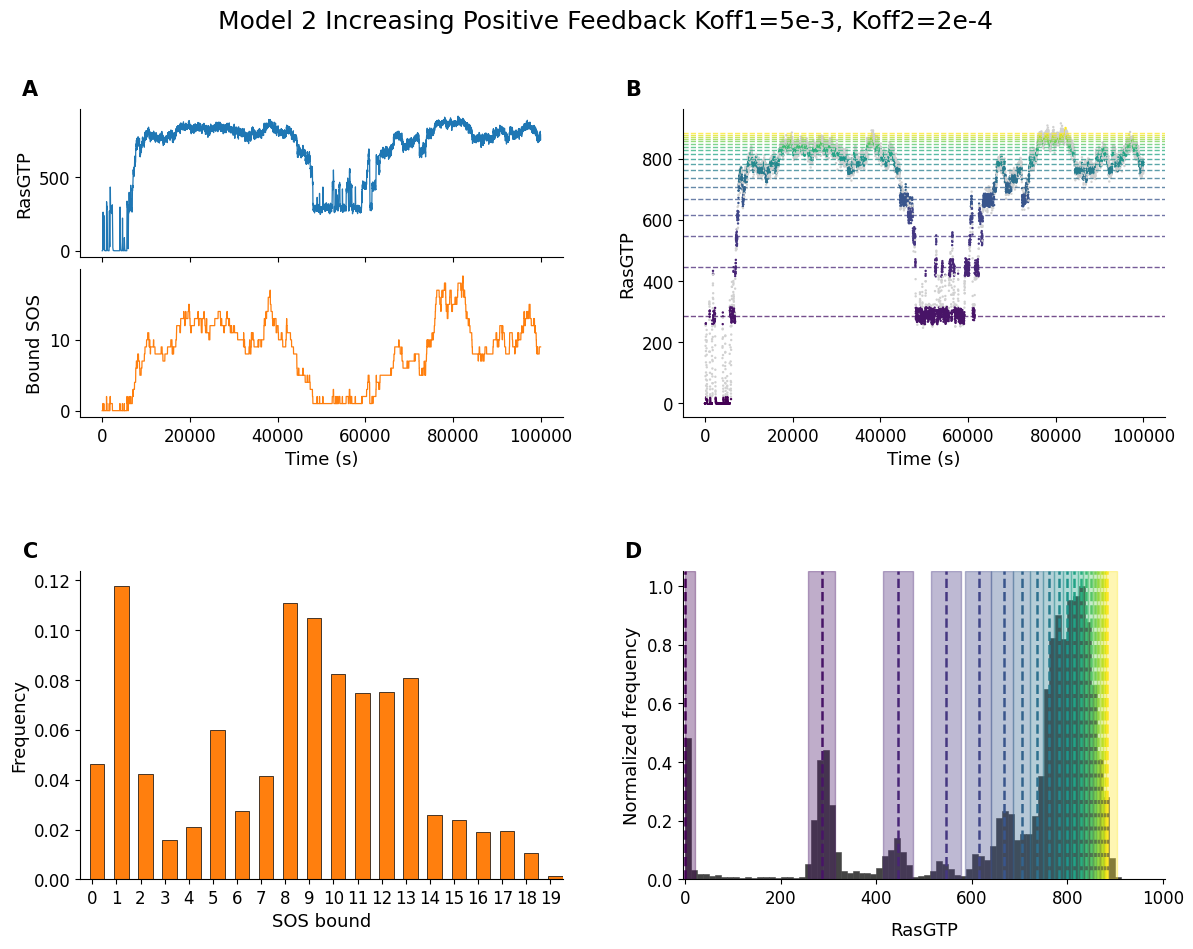

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import bionetgen                       


MODEL      = "Model2"          
PVAL       = [1, 15, 30]        # RhoSOS values (nM)
KOFF1      = 5e-3              
KOFF2      = 2e-4           # 5e-4 Model 2 
T_END      = 100000               # simulation end time (s)
N_STEPS    = 10000           


Kcat1      = 1e-2             
Kcat2      = 2.5e-2           
RasTotal   = 1000               

N_SIGMA    = 2                 # half-width of occupancy windows (×σ)
N_BINS     = 80                # bins for RasGTP histogram (panel D)


model = bionetgen.bngmodel(MODEL + ".bngl")
sim   = model.setup_simulator()
sim.setIntegrator('gillespie')


# SIMULATION 
indices    = list(range(len(PVAL)))
traj_no_fb = []

for idx in indices:
    sim.reset()
    sim.Koff1  = KOFF1
    sim.Koff2  = KOFF2
    sim.RhoSOS = PVAL[idx]

    result = sim.simulate(0, T_END, N_STEPS)
    traj_no_fb.append(result)

time_vals     = np.asarray(traj_no_fb[0]["time"])
ras_vals      = np.asarray(traj_no_fb[0]["totalRasGTP"])
boundras_vals = np.asarray(traj_no_fb[0]["totalBoundRas"])

#THEORETICAL

def mean_rasgtp(n, Kcat1, Kcat2, RasTotal):
    """Expected RasGTP when n SOS sites are bound."""
    total_rate = n * Kcat1 + Kcat2
    if total_rate == 0:
        return 0.0
    pn = n * Kcat1 / total_rate
    return RasTotal * pn


def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width (standard deviation)."""
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))


def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    +/- n_sigma·σₙ windows around each predicted peak,
    capped at midpoints between neighbours so windows never overlap.
    """
    sigmas = []
    ranges = []

    for i, n in enumerate(n_bound_list):
        ss  = ss_array[i]
        sig = sigma(n, Kcat1, Kcat2, RasTotal)
        sigmas.append(sig)

        half = 20 if n == 0 else n_sigma * sig
        lo = ss - half
        hi = ss + half

        if i > 0:                          # cap left edge
            lo = max(lo, 0.5 * (ss_array[i - 1] + ss))
        if i < len(ss_array) - 1:         # cap right edge
            hi = min(hi, 0.5 * (ss + ss_array[i + 1]))

        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))

    return ranges, sigmas

max_sos      = int(boundras_vals.max()) if boundras_vals.size else 4
n_bound_list = list(range(max_sos + 1))
R_ss_array   = np.array([mean_rasgtp(n, Kcat1, Kcat2, RasTotal)
                          for n in n_bound_list])

quantized_ranges, sigmas_list = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=N_SIGMA
)

# TABLES
print(f"\n{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} width")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array,
                                 sigmas_list, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")


state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")

#FOR PLOTTING 

colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

def assign_dot_colors(ras_vals, bound_vals, quantized_ranges, n_bound_list, colors):
    """COLOR by occupancy n, grey when outside window."""
    grey   = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)

    for i, ((lo, hi), n) in enumerate(zip(quantized_ranges, n_bound_list)):
        mask = (bound_vals == n) & (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]

    return result


def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """Fraction of histogram within each theory window."""
    total  = counts_norm.sum()
    stats  = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt    = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0,
        })
    return stats


dot_colors = assign_dot_colors(ras_vals, boundras_vals,
                                quantized_ranges, n_bound_list, colors)

# RasGTP histogram (panels D)
counts, edges = np.histogram(ras_vals, bins=N_BINS, range=(0, RasTotal))
counts_norm   = counts / counts.max() if counts.max() > 0 else counts
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

range_stats      = quantize_histogram(counts_norm, bin_centers,
                                      quantized_ranges, n_bound_list, R_ss_array)
pct_quantized    = sum(s['pct'] for s in range_stats)
print(f"\nTotal % in windows: {pct_quantized:.1f}%\n")

# 4 panel figure 

LABEL_SIZE  = 12
AXIS_SIZE   = 13
PANEL_SIZE  = 15

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig   = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.5)

innerA    = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                             hspace=0.08, height_ratios=[1, 1])
ax_A_top  = fig.add_subplot(innerA[0])
ax_A_bot  = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B      = fig.add_subplot(outer[0, 1])
ax_C      = fig.add_subplot(outer[1, 0])
ax_D      = fig.add_subplot(outer[1, 1])

#  Panel labels 
for letter, ax in zip(['A', 'B', 'C', 'D'],
                       [ax_A_top, ax_B, ax_C, ax_D]):
    pos = ax.get_position()
    fig.text(pos.x0 - 0.03, pos.y1 + 0.01, letter,
             fontsize=PANEL_SIZE, fontweight='bold', va='bottom', ha='right')

#  Panel A — Dual time course 
ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)

ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  Panel B — Scatter colored by instantaneous SOS occupancy
ax_B.scatter(time_vals, ras_vals,
             c=dot_colors, s=3, linewidths=0, rasterized=True)

for ss, col in zip(R_ss_array, colors):
    if ss > 0:
        ax_B.axhline(ss, color=col, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time (s)', fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP',   fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

# ── Panel C — SOS-bound occupancy histogram 
max_bound    = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_w    = 0.6
sos_bins     = np.arange(max_bound + 2) - 0.5 * sos_bar_w

ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          rwidth=sos_bar_w, color=color_bras,
          edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound', fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency', fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

# ── Panel D — Quantized RasGTP histogram 
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444',
         linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.05)
ax_D.set_xlim(-5, RasTotal + 5)

for s, col in zip(range_stats, colors):
    ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=col, zorder=3)
    ax_D.axvline(s['ss_val'], color=col, lw=1.8, ls='--', zorder=4)

ax_D.set_xlabel('RasGTP',              fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)

fig.suptitle(
    "Model 2 Increasing Positive Feedback Koff1=5e-3, Koff2=2e-4",
    fontsize=18, y=0.98
)

plt.tight_layout()
plt.show()
